In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seaborn as sns
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.abspath(".."))

from src.constants import (
    N_COMPONENTS_PLS, N_COMPONENTS_PCA, REDUCTION_METHOD, ASSET_COLS, 
    COLOR_EXP as COLOR_0, COLOR_REC as COLOR_1, SHADE_COL, SHADE_A, LW)
from src.data_loader import load_macro_data, load_asset_data
from src.preprocess import prepare_macro_data, apply_dim_reduction, loading_table, train_test_split
from src.hmm_model import HMMRegimeModel
from src.plots import (plot_regime_states, plot_regime_probs, plot_regime_nber, _fmt_matrix)
from src.portfolio import (estimate_regime_moments, optimize_regimes,
                            shrinkage_diagnostics)
from src.metrics import compute_metrics
from src.backtest import run_backtest, print_metrics_table

BASE_DIR           = Path('..')
DATA_DIR           = BASE_DIR / 'data'
OUTPUT_TABLES_DIR  = BASE_DIR / 'outputs' / 'tables'
OUTPUT_FIGURES_DIR = BASE_DIR / 'outputs' / 'figures'
OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def get_smoothed_probs(model, X): return model.smoothed_probs(X)
def get_filtered_probs(model, X): return model.filtered_probs(X)

plot_hmm_states      = lambda d, s, title="HMM Regime States": plot_regime_states(d, s, title)
plot_hmm_state_probs = lambda d, p, title="HMM State Probabilities": plot_regime_probs(d, p, title)

## Description

- Goal: implement GMV and MVO to determine optimal portfolio weights with state-conditional asset returns and covariance matrix (with shrinkage)
- Methodology:
  - Step 1: Use 15 macroeconomic indicators with dimentionality reduction techniques (PCA and PLS) to classify states (K=2)
  - Step 2: Estimate state-conditional mean and covariance (Ledoit-Wolf shrinkage for covariance and Bayes-Stein for means)
  - Step 3: Implement GMV and MVO for each state to determine optimal portfolio weights
  - Step 4: Export .csv files containing the target weights to be used for backtesting



## Data preparation

Standardize macroeconomic indicators and prepare train/test arrays.

In [2]:
macro_df = load_macro_data("../data/macro_clean.csv")
macro_df.head()

,industrial_production,real_person_income,unemployment_rate,initial_jobless_claims,continuing_claims,cpi,oil_price,vix,credit_spread,yield_curve_slope,fed_funds_rate,consumer_sentiment,housing_starts,m2_money_supply,dollar_index
Date,,,,,,,,,,,,,,,
1990-02-28,0.766740,0.213257,-0.176815,0.086523,0.140235,0.648227,-0.517277,0.338459,-0.860618,-1.015353,0.112648,-0.816259,-0.971936,-0.116878,0.017130
1990-03-31,0.370899,-0.142952,-0.176815,-0.056857,0.082572,0.933078,-0.577370,0.033559,-1.001067,-1.092009,0.277788,0.453545,-1.385261,-0.207448,1.046560
1990-04-30,-0.367268,0.582737,0.366229,0.272514,0.167186,0.056672,-0.934117,0.005227,-1.113426,-1.015353,-0.052492,0.645214,-0.409511,-0.174649,-0.009542
1990-05-31,0.183034,-0.438133,0.004200,-0.054564,0.122786,-0.234552,-0.572546,-0.284832,-0.818483,-0.993451,-0.382773,-0.768342,-0.370488,-0.904505,-0.734113
1990-06-30,0.216958,-0.097920,-0.357829,0.083436,0.050709,1.493735,-0.255118,-0.537116,-0.706123,-0.894894,0.663116,-0.528756,-0.370905,-0.083910,-0.013835


In [3]:
macro_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   industrial_production   431 non-null    float64
 1   real_person_income      431 non-null    float64
 2   unemployment_rate       431 non-null    float64
 3   initial_jobless_claims  431 non-null    float64
 4   continuing_claims       431 non-null    float64
 5   cpi                     431 non-null    float64
 6   oil_price               431 non-null    float64
 7   vix                     431 non-null    float64
 8   credit_spread           431 non-null    float64
 9   yield_curve_slope       431 non-null    float64
 10  fed_funds_rate          431 non-null    float64
 11  consumer_sentiment      431 non-null    float64
 12  housing_starts          431 non-null    float64
 13  m2_money_supply         431 non-null    float64
 14  dollar_index            431 non-nu

In [4]:
# asset data 
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431 entries, 1990-02-28 to 2025-12-31
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index_fund     431 non-null    float64
 1   treasury_fund  431 non-null    float64
 2   gold_fund      431 non-null    float64
dtypes: float64(3)
memory usage: 13.5 KB


In [5]:

# split and standardize macro data using robust scaler
X_train, X_test, scaler, dates_train, dates_test = prepare_macro_data(macro_df)


In [6]:
# train data for PLS 
Y_train = asset_df.loc[dates_train, ASSET_COLS].values

### Data dimensionality reduction


── PLS summary ──
  Input dimensions  : 15
  Components        : 4
  X variance explained (approx): 56.2%
  Projected train shape : (431, 4)


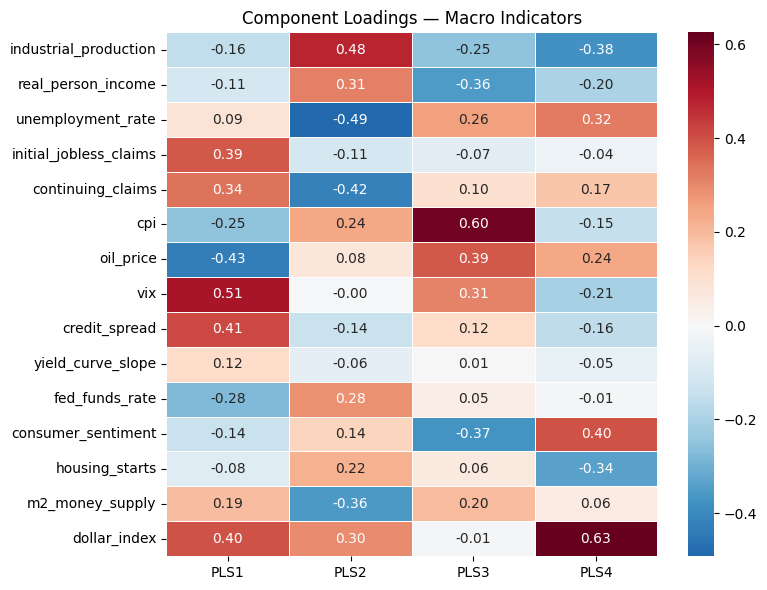

,PLS1,PLS2,PLS3,PLS4
industrial_production,-0.155367,0.476632,-0.250177,-0.375319
real_person_income,-0.110352,0.311958,-0.356620,-0.195295
unemployment_rate,0.086308,-0.492188,0.257219,0.320805
initial_jobless_claims,0.387559,-0.110333,-0.072323,-0.035883
continuing_claims,0.338862,-0.421261,0.097726,0.174842
cpi,-0.251821,0.238648,0.602285,-0.149768
oil_price,-0.426903,0.075964,0.388887,0.237250
vix,0.514007,-0.003841,0.307376,-0.206161
credit_spread,0.412232,-0.141044,0.121052,-0.156793
yield_curve_slope,0.120800,-0.061946,0.005553,-0.050879


In [7]:
if REDUCTION_METHOD == 'pls':
    N_COMPONENTS = N_COMPONENTS_PLS
elif REDUCTION_METHOD == 'pca':
    N_COMPONENTS = N_COMPONENTS_PCA
else:
    N_COMPONENTS = None
X_train_reduced, X_test_reduced, reducer = apply_dim_reduction(X_train, X_test, 
                                                   method=REDUCTION_METHOD, 
                                                   Y_train=Y_train,
                                                   n_components=N_COMPONENTS)
# Loadings heatmap
loadings = loading_table(reducer, macro_df.columns.tolist())
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5)
plt.title('Component Loadings — Macro Indicators')
plt.tight_layout()
plt.savefig(f'../outputs/figures/{REDUCTION_METHOD}_loadings_hmm.png', dpi=150,
            bbox_inches='tight')
plt.show()
display(loadings)

## Model fitting

In [8]:
model = HMMRegimeModel(
    n_states=2,
    n_iter=200,
    n_restarts=10,
    covariance_type='full',
    sort_method='trace',   # or 'pc1_mean' or 'naive'
)
model.fit(X_train_reduced)

Best log-likelihood (per sample): -2176.1202
Sort method: 'trace'
Transition matrix:
[[0.94162491 0.05837509]
 [0.15548727 0.84451273]]
State durations (months): ['17.1', '6.4']
State 0 = Expansion  (tr(Σ)=2.0086  PC1_mean=-0.295)
State 1 = Recession  (tr(Σ)=8.4241  PC1_mean=0.641)


## Extracting results

In [9]:
smoothed_probs_train = get_smoothed_probs(model, X_train_reduced)
print("Smoothed probs shape:", smoothed_probs_train.shape)
print("Sum to 1:", np.allclose(smoothed_probs_train.sum(axis=0), 1.0))

Smoothed probs shape: (2, 431)
Sum to 1: True


In [10]:
filtered_probs_train = get_filtered_probs(model, X_train_reduced)
print("Filtered probs shape:", filtered_probs_train.shape)
print("Sum to 1:", np.allclose(filtered_probs_train.sum(axis=0), 1.0))

Filtered probs shape: (2, 431)
Sum to 1: True


In [11]:
states_sequence = model.predict(X_train_reduced)
print("State counts:", np.unique(states_sequence, return_counts=True))

State counts: (array([0, 1]), array([320, 111]))


In [12]:
states_sequence_series = pd.Series(states_sequence, index=dates_train, name="HMM State")
states_sequence_series.value_counts()

HMM State
0    320
1    111
Name: count, dtype: int64

### Transition matrix

In [13]:
pd.DataFrame(model.transmat_,
             columns=[f"State {i}" for i in range(model.n_components)],
             index=[f"State {i}" for i in range(model.n_components)])

,State 0,State 1
State 0,0.941625,0.058375
State 1,0.155487,0.844513


In [14]:
print(f"Average duration in each state (expected number of consecutive months):")
for i, persistent_prob in enumerate(model.transmat_.diagonal()):
    print(f"State {i}: {1 / (1 - persistent_prob):.2f} months")

Average duration in each state (expected number of consecutive months):
State 0: 17.13 months
State 1: 6.43 months


### Conditional means and covariance matrices

In [15]:
if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]

pd.DataFrame(
    model.means_,
    columns=component_names,
    index=['State 0', 'State 1']
).T

,State 0,State 1
PLS1,-0.295159,0.641302
PLS2,0.082881,-0.011577
PLS3,-0.176716,0.451399
PLS4,0.100833,-0.256065


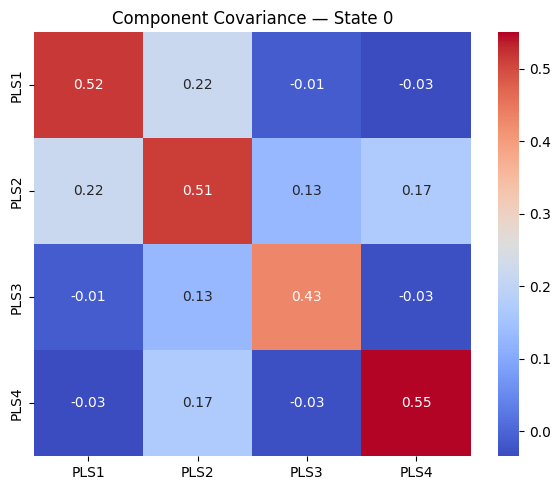

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[0], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('Component Covariance — State 0')
plt.tight_layout()
plt.show()


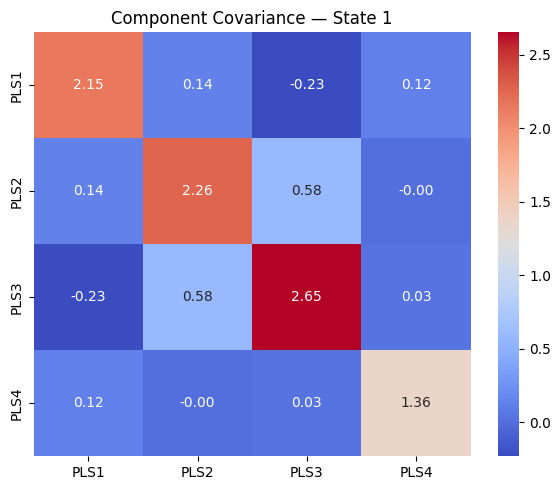

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(model.covars_[1], annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=component_names, yticklabels=component_names)
plt.title('Component Covariance — State 1')
plt.tight_layout()
plt.show()


## Plotting results

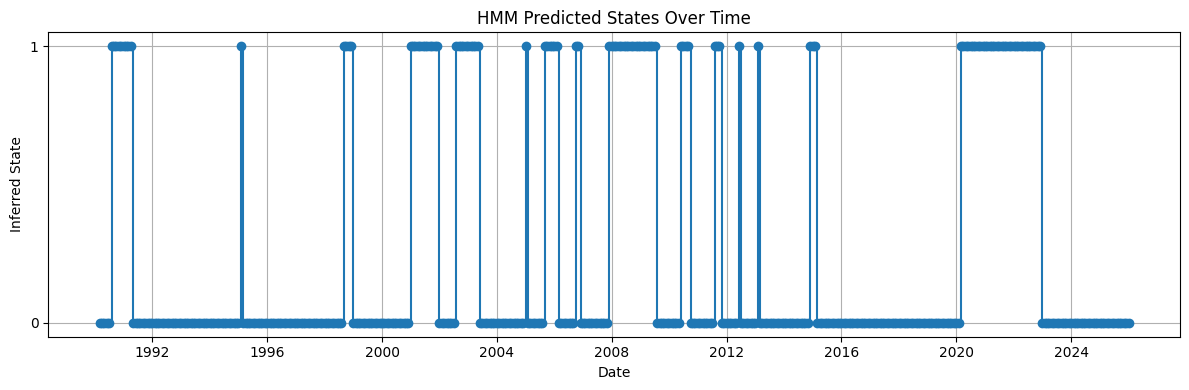

In [18]:
plot_hmm_states(dates_train, states_sequence, title="HMM Predicted States Over Time")
plt.show()

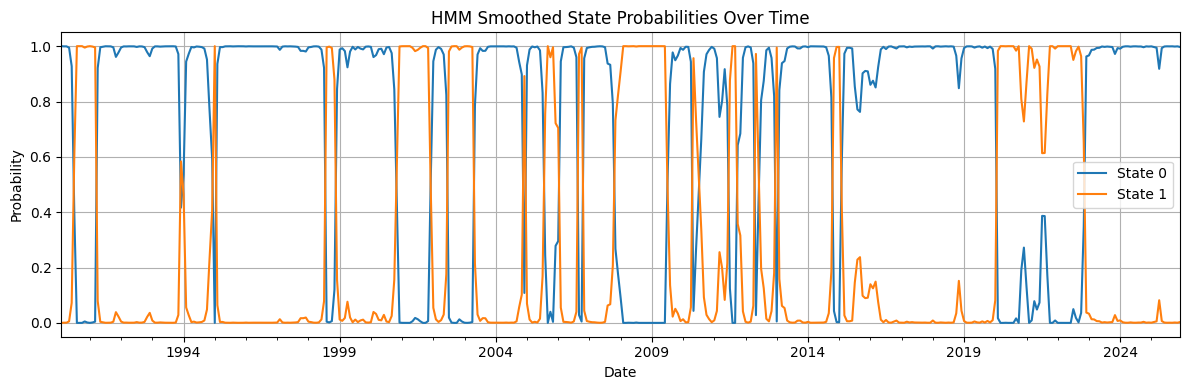

In [19]:
plot_hmm_state_probs(dates_train, smoothed_probs_train,
                     title="HMM Smoothed State Probabilities Over Time")
plt.show()

In [20]:
# number of instances with probabilities between 0.2 and 0.8
p0 = filtered_probs_train[0, :]
((p0 >= 0.3) & (p0 <= 0.7)).sum().item()

28

In [21]:
macro_df_expanded = macro_df.copy()
macro_df_expanded["HMM State"] = states_sequence

In [22]:
asset_df = load_asset_data("../data/market_clean.csv")
asset_df.columns = ['Equity', 'Bonds', 'Gold']
asset_df_expanded = asset_df.copy()
asset_df_expanded["HMM State"] = macro_df_expanded["HMM State"]

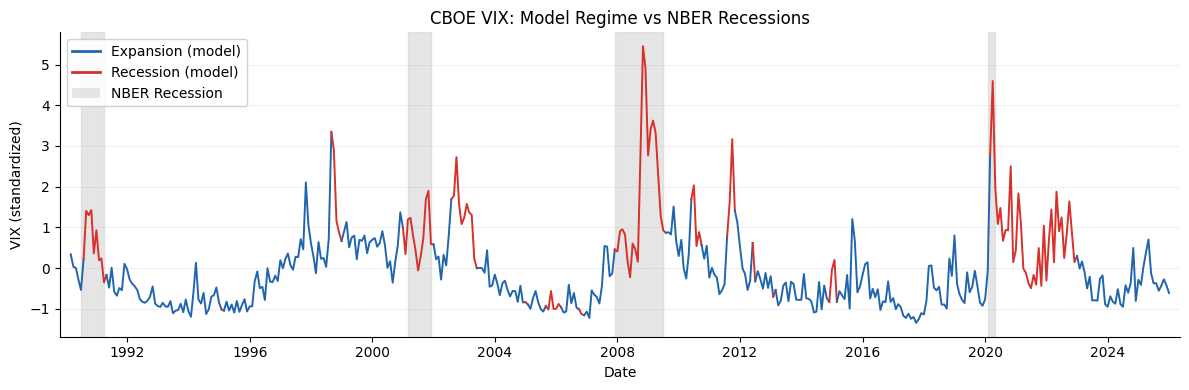

In [23]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='vix', state_col='HMM State',
    recession_state=1,
    title='CBOE VIX: Model Regime vs NBER Recessions',
    ylabel='VIX (standardized)', ax=ax
)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / f'hmm_{REDUCTION_METHOD}_states_vs_nber_vix.png',
            dpi=150, bbox_inches='tight')
plt.show()

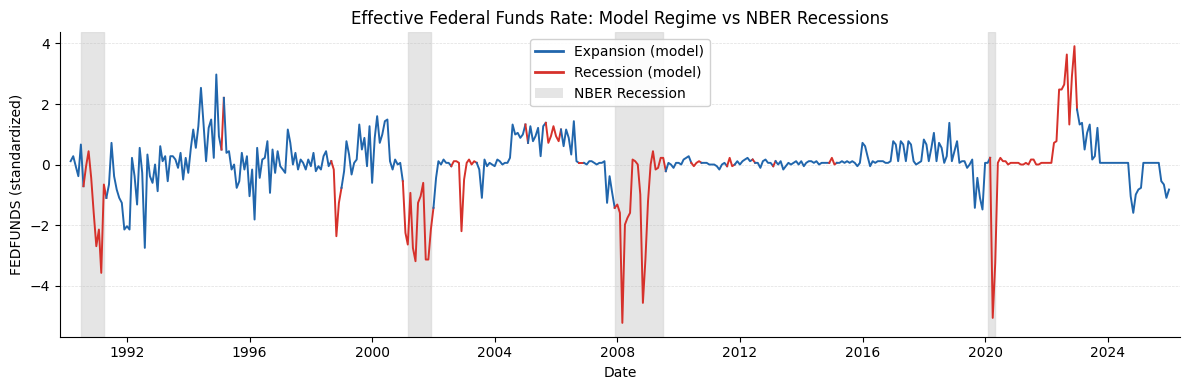

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_regime_nber(
    macro_df_expanded, series_name='fed_funds_rate', state_col='HMM State',
    recession_state=1,
    title='Effective Federal Funds Rate: Model Regime vs NBER Recessions',
    ylabel='FEDFUNDS (standardized)', ax=ax
)
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / f'hmm_{REDUCTION_METHOD}_states_vs_nber_rfr.png',
            dpi=150, bbox_inches='tight')
plt.show()

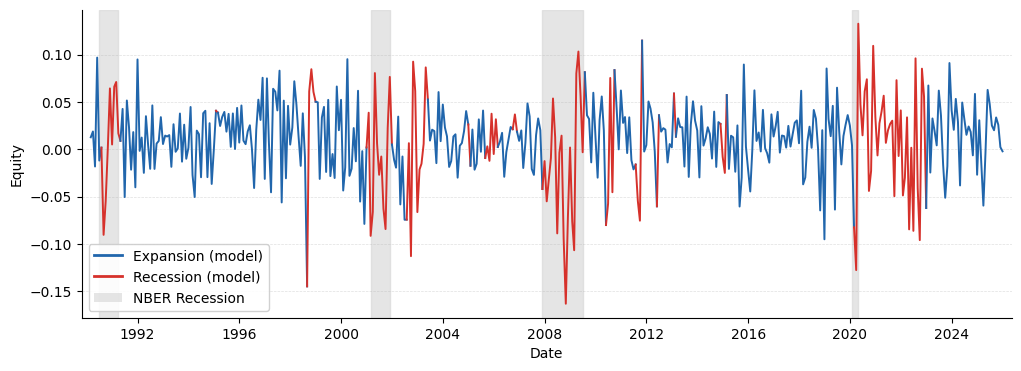

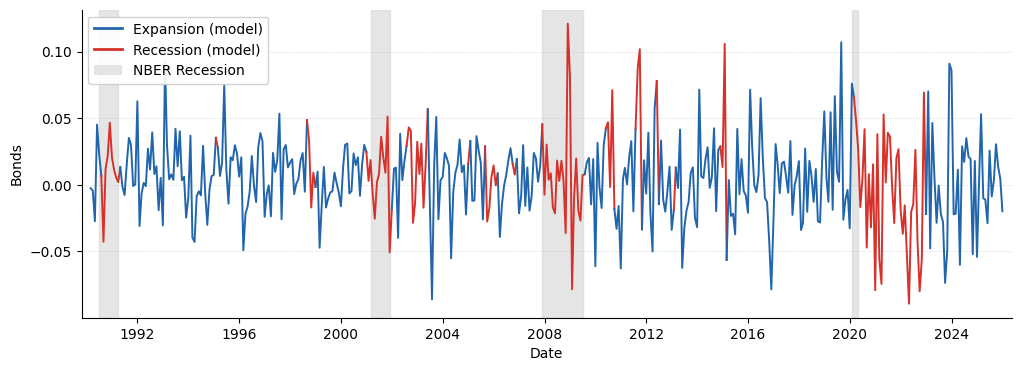

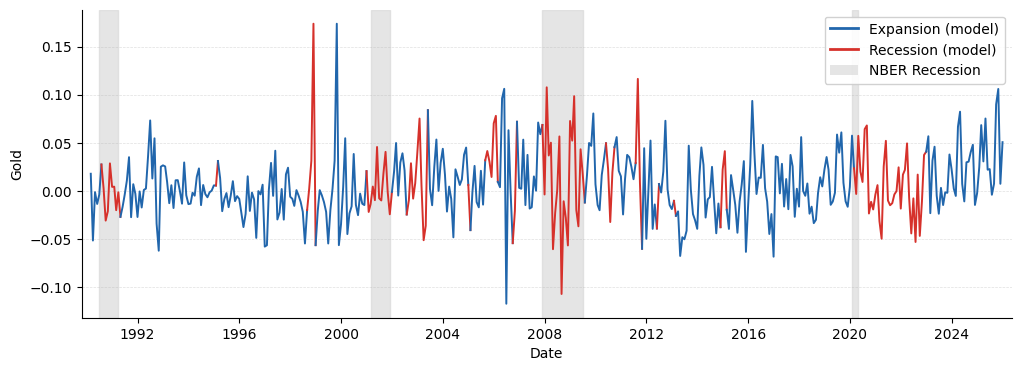

In [25]:
for col in asset_df.columns:
    plot_regime_nber(asset_df_expanded, series_name=col, state_col="HMM State", ax=None)
    plt.show()

## Portfolio optimization

Regime-conditional optimal weights using Ledoit-Wolf and Bayes-Stein estimated on the training set.

In [26]:
market_train, market_test = train_test_split(asset_df_expanded)
print("Last train date:", market_train.index[-1])
print("First test date:", market_test.index[0])

Last train date: 2018-09-30 00:00:00
First test date: 2018-10-31 00:00:00


In [27]:
ASSET_NAMES = market_train.columns[:-1].tolist()  # Exclude 'HMM State' column

In [28]:
# regime-conditional moments with shrinkage methods
moments = estimate_regime_moments(market_train,
                                  asset_cols=ASSET_NAMES,
                                  state_col="HMM State")


── Regime 0  (267 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample +16.11%  →  BS +14.16%
    Bonds           : sample +4.40%  →  BS +5.55%
    Gold            : sample +2.18%  →  BS +3.12%
  Bayes-Stein φ  : 0.3576  (mild shrinkage)
  Ledoit-Wolf α  : 0.3710
  Implied annual volatilities (shrunk Σ):
    Equity          : 10.99%
    Bonds           : 9.73%
    Gold            : 11.29%

── Regime 1  (77 observations) ──
  Mean returns — sample vs Bayes-Stein (annualized %):
    Equity          : sample -8.24%  →  BS -1.97%
    Bonds           : sample +18.77%  →  BS +15.07%
    Gold            : sample +14.00%  →  BS +10.95%
  Bayes-Stein φ  : 0.3319  (mild shrinkage)
  Ledoit-Wolf α  : 0.2205
  Implied annual volatilities (shrunk Σ):
    Equity          : 19.87%
    Bonds           : 13.15%
    Gold            : 15.57%


In [29]:
shrinkage_diagnostics(moments, asset_cols=ASSET_NAMES)


── Ledoit-Wolf shrinkage effect (shrunk Σ − raw Σ) ──

Regime 0  (α = 0.3710):
          Equity   Bonds    Gold
  Equity-0.00004-0.00002 0.00001
   Bonds-0.00002 0.00009-0.00006
    Gold 0.00001-0.00006-0.00007

Regime 1  (α = 0.2205):
          Equity   Bonds    Gold
  Equity-0.00034 0.00013 0.00009
   Bonds 0.00013 0.00021-0.00003
    Gold 0.00009-0.00003 0.00004


In [30]:
# asset_names = market_train.columns[:-1]

print("=" * 55)
print("Regime-Conditional Optimal Weights")
print("=" * 55)
results = optimize_regimes(moments, ASSET_NAMES, rf=0.0, long_only=True)

print("\n" + "=" * 55)
print("=" * 55)
plt.show()


Regime-Conditional Optimal Weights

── min_variance  |  Regime 0 ──
  Expected return (ann.) : +7.68%
  Volatility     (ann.) : 6.37%
  Sharpe ratio          : 1.2061
  Weights:
    Equity        : 0.3291  (32.9%)
    Bonds         : 0.3820  (38.2%)
    Gold          : 0.2889  (28.9%)

── max_sharpe  |  Regime 0 ──
  Expected return (ann.) : +10.55%
  Volatility     (ann.) : 7.47%
  Sharpe ratio          : 1.4137
  Weights:
    Equity        : 0.6132  (61.3%)
    Bonds         : 0.2733  (27.3%)
    Gold          : 0.1135  (11.4%)

── min_variance  |  Regime 1 ──
  Expected return (ann.) : +9.48%
  Volatility     (ann.) : 8.22%
  Sharpe ratio          : 1.1531
  Weights:
    Equity        : 0.2566  (25.7%)
    Bonds         : 0.4462  (44.6%)
    Gold          : 0.2971  (29.7%)

── max_sharpe  |  Regime 1 ──
  Expected return (ann.) : +12.57%
  Volatility     (ann.) : 9.46%
  Sharpe ratio          : 1.3279
  Weights:
    Equity        : 0.0736  (7.4%)
    Bonds         : 0.6224  (62.2%)


### Target weights export

Exports GMV (`min_variance`) and MVO (`max_sharpe`) target weights for every date
in the training period.  These CSVs are loaded by `05_backtesting.ipynb`.


In [31]:
output_path = os.path.join('..', 'outputs/tables')
os.makedirs(output_path, exist_ok=True)

for label, obj in [('gmv', 'min_variance'), ('mvo', 'max_sharpe')]:
    weights_by_regime = {k: results[k][obj].weights for k in results}
    rows = []
    for date, regime in states_sequence_series.items():
        w = weights_by_regime[regime]
        rows.append({
            'Date':   date,
            'Regime': regime,
            'Equity': w[0],
            'Bonds':  w[1],
            'Gold':   w[2],
        })
    fname = f'hmm_{REDUCTION_METHOD}_{label}_target_weights.csv'
    pd.DataFrame(rows).to_csv(os.path.join(output_path, fname), index=False)
    print(f'Saved {fname}')
    display(pd.DataFrame(rows).head(3))


Saved hmm_pls_gmv_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-02-28,0,0.329051,0.382037,0.288912
1,1990-03-31,0,0.329051,0.382037,0.288912
2,1990-04-30,0,0.329051,0.382037,0.288912


Saved hmm_pls_mvo_target_weights.csv


,Date,Regime,Equity,Bonds,Gold
0,1990-02-28,0,0.613159,0.273324,0.113517
1,1990-03-31,0,0.613159,0.273324,0.113517
2,1990-04-30,0,0.613159,0.273324,0.113517


The recession regime has far fewer observations (~15-20 months vs ~150+ for expansion). Bayes-Stein shrinkage pulls the recession-regime mean toward the grand mean, making the MVO weights more conservative and less sensitive to noisy estimates.


## Robustness Check: K = 3 Regimes

AIC and BIC are used for model comparison (LR test is non-standard under H0: K=2 per Garcia 1998).

In [32]:
model_k3 = HMMRegimeModel(
    n_states=3,
    n_iter=200,
    n_restarts=10,
    covariance_type='full',
    sort_method='trace',   # or 'pc1_mean' or 'naive'
)
model_k3.fit(X_train_reduced)

Best log-likelihood (per sample): -2100.6779
Sort method: 'trace'
Transition matrix:
[[0.94900554 0.03992137 0.01107309]
 [0.0334929  0.91030948 0.05619763]
 [0.04695618 0.07147743 0.88156639]]
State durations (months): ['19.6', '11.1', '8.4']
State 0 = Expansion  (tr(Σ)=1.8876  PC1_mean=-0.612)
State 1 = Recession  (tr(Σ)=2.4696  PC1_mean=0.153)


In [33]:
# After PCA, N is the number of components, not the original 13.
T, N = X_train_reduced.shape

def hmm_n_params(K, N):
    return (K - 1) + K * (K - 1) + K * N + K * N * (N + 1) // 2

ll_k2 = model.score(X_train_reduced)
ll_k3 = model_k3.score(X_train_reduced)

np_k2 = hmm_n_params(2, N)
np_k3 = hmm_n_params(3, N)

lr_stat = 2 * (ll_k3 - ll_k2)
delta_df = np_k3 - np_k2

summary_k3 = pd.DataFrame({
    'K': [2, 3],
    'Log-Likelihood': [ll_k2, ll_k3],
    'N Parameters':   [np_k2, np_k3],
    'AIC': [-2*ll_k2 + 2*np_k2, -2*ll_k3 + 2*np_k3],
    'BIC': [-2*ll_k2 + np_k2*np.log(T), -2*ll_k3 + np_k3*np.log(T)],
})
print(f'LR statistic (K=2 vs K=3): {lr_stat:.2f}  (delta_df = {delta_df})')
print('Note: LR p-value non-standard under H0 — use AIC/BIC.')
summary_k3

LR statistic (K=2 vs K=3): 150.88  (delta_df = 19)
Note: LR p-value non-standard under H0 — use AIC/BIC.


,K,Log-Likelihood,N Parameters,AIC,BIC
0,2,-2176.120203,31,4414.240407,4540.289757
1,3,-2100.677872,50,4301.355745,4504.661149


In [34]:
states_k3 = model_k3.predict(X_train_reduced)
print('K=3 state counts:', dict(zip(*np.unique(states_k3, return_counts=True))))


if hasattr(reducer, 'n_components_'):   # PCA
    n_comp = reducer.n_components_
    component_names = [f'PC{j+1}'  for j in range(n_comp)]
else:                                    # PLS
    n_comp = reducer.n_components
    component_names = [f'PLS{j+1}' for j in range(n_comp)]
means_k3 = pd.DataFrame(
    model_k3.means_,
    columns=component_names,
    index=[f'State {k}' for k in range(3)]
).T

# After PCA the index is PC1..PC6, not original variable names.
# Display all components — with only 6 rows there is nothing to filter.
means_k3

K=3 state counts: {np.int64(0): np.int64(181), np.int64(1): np.int64(158), np.int64(2): np.int64(92)}


,State 0,State 1,State 2
PLS1,-0.611939,0.153242,0.720998
PLS2,0.120814,0.032336,-0.021861
PLS3,-0.372328,-0.101236,0.863287
PLS4,0.259530,-0.058702,-0.378960


In [35]:
# Optional: show which original indicators each PC represents
loadings = loading_table(reducer, macro_df.columns.tolist())
print("Component means by state:")
display(means_k3)
# print("\nFor economic interpretation, cross-reference with loadings:")
# display(loadings)

Component means by state:


,State 0,State 1,State 2
PLS1,-0.611939,0.153242,0.720998
PLS2,0.120814,0.032336,-0.021861
PLS3,-0.372328,-0.101236,0.863287
PLS4,0.259530,-0.058702,-0.378960
